#Instalasi Library

In [ ]:
# jalankan sekali di Colab
#!pip install scikit-fuzzy pygad tensorflow -q

In [ ]:
import numpy as np                          # operasi numerik & array
import pandas as pd                         # manipulasi dataframe
import matplotlib.pyplot as plt             # visualisasi grafik
import matplotlib.patches as mpatches
import json                                 # simpan/load konfigurasi model
import pickle                               # serialisasi objek Python
import warnings
warnings.filterwarnings('ignore')

# ── Scikit-learn: preprocessing & evaluasi ──
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ── Scikit-fuzzy: fuzzy logic / FIS Mamdani ──
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# ── PyGAD: Genetic Algorithm ──
import pygad

# ── TensorFlow/Keras: Artificial Neural Network ──
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

print("Semua library berhasil diimport!")
print(f"   TensorFlow versi : {tf.__version__}")
print(f"   PyGAD versi      : {pygad.__version__}")


Semua library berhasil diimport!
   TensorFlow versi : 2.19.0
   PyGAD versi      : 3.6.0


#Load Dataset

In [ ]:
# Google Colab: upload file CSV dari komputer lokal
from google.colab import files
uploaded = files.upload()
df_raw = pd.read_csv(list(uploaded.keys())[0])

# lokal / lingkungan lain: ganti path sesuai lokasi file
#df_raw = pd.read_csv('ispu_dki_all.csv')

print(f"Shape dataset: {df_raw.shape}")
print(f"Kolom: {df_raw.columns.tolist()}")


Saving ispu_dki_all.csv to ispu_dki_all (4).csv
Shape dataset: (5538, 11)
Kolom: ['tanggal', 'stasiun', 'pm25', 'pm10', 'so2', 'co', 'o3', 'no2', 'max', 'critical', 'categori']


In [ ]:
# 5 baris pertama
df_raw.head()

,tanggal,stasiun,pm25,pm10,so2,co,o3,no2,max,critical,categori
0,2010-01-01,DKI1 (Bunderan HI),NaN,60.0,4.0,73.0,27.0,14.0,73.0,CO,SEDANG
1,2010-01-02,DKI1 (Bunderan HI),NaN,32.0,2.0,16.0,33.0,9.0,33.0,O3,BAIK
2,2010-01-03,DKI1 (Bunderan HI),NaN,27.0,2.0,19.0,20.0,9.0,27.0,PM10,BAIK
3,2010-01-04,DKI1 (Bunderan HI),NaN,22.0,2.0,16.0,15.0,6.0,22.0,PM10,BAIK
4,2010-01-05,DKI1 (Bunderan HI),NaN,25.0,2.0,17.0,15.0,8.0,25.0,PM10,BAIK


In [ ]:
# Informasi tipe data dan jumlah non-null
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5538 entries, 0 to 5537
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   tanggal   5538 non-null   object 
 1   stasiun   5537 non-null   object 
 2   pm25      1516 non-null   float64
 3   pm10      5223 non-null   float64
 4   so2       5408 non-null   float64
 5   co        5450 non-null   float64
 6   o3        5434 non-null   float64
 7   no2       5432 non-null   float64
 8   max       5537 non-null   float64
 9   critical  5534 non-null   object 
 10  categori  5538 non-null   object 
dtypes: float64(7), object(4)
memory usage: 476.1+ KB


In [ ]:
# Statistik deskriptif
df_raw.describe()


,pm25,pm10,so2,co,o3,no2,max
count,1516.000000,5223.000000,5408.000000,5450.000000,5434.000000,5432.000000,5537.000000
mean,89.742084,56.407046,22.436206,20.422752,77.465771,14.349227,97.625790
std,26.615960,20.010963,15.450584,11.966246,51.798101,10.051099,40.955382
min,10.000000,2.000000,0.000000,0.000000,4.000000,1.000000,0.000000
25%,71.000000,45.000000,10.000000,12.000000,36.000000,8.000000,70.000000
50%,90.000000,57.000000,18.000000,18.000000,69.000000,12.000000,90.000000
75%,107.000000,67.000000,32.000000,26.000000,103.000000,18.000000,114.000000
max,287.000000,187.000000,112.000000,119.000000,314.000000,202.000000,314.000000


In [ ]:
# Distribusi label target
print("Distribusi kategori kualitas udara:")
print(df_raw['categori'].value_counts())


Distribusi kategori kualitas udara:
categori
SEDANG                3187
TIDAK SEHAT           1827
BAIK                   316
SANGAT TIDAK SEHAT     203
TIDAK ADA DATA           4
BERBAHAYA                1
Name: count, dtype: int64


#Data Preprocessing

In [ ]:
# Langkah 1: Hapus baris 'TIDAK ADA DATA'
df = df_raw[df_raw['categori'] != 'TIDAK ADA DATA'].copy()
print(f"Data setelah hapus 'TIDAK ADA DATA': {len(df)} baris")


Data setelah hapus 'TIDAK ADA DATA': 5534 baris


In [ ]:
# Langkah 2: Mapping kategori ke 5 kelas
# Gabungkan 'SANGAT TIDAK SEHAT' dan 'BERBAHAYA' --> 'Berbahaya'
kategori_map = {
    'BAIK'               : 'Sangat Aman',
    'SEDANG'             : 'Aman',
    'TIDAK SEHAT'        : 'Tidak Sehat',
    'SANGAT TIDAK SEHAT' : 'Berbahaya',
    'BERBAHAYA'          : 'Berbahaya'
}
df['label'] = df['categori'].map(kategori_map)
print("Distribusi label setelah mapping:")
print(df['label'].value_counts())


Distribusi label setelah mapping:
label
Aman           3187
Tidak Sehat    1827
Sangat Aman     316
Berbahaya       204
Name: count, dtype: int64


In [ ]:
# --- Langkah 3: Feature selection (DISELARASKAN) ---
# Gunakan fitur yang sama karena ANN akan men-tuning parameter FIS
FITUR_SAMA = ['pm25', 'pm10', 'co']
TARGET     = 'label'

# --- Langkah 4: Handle missing values ---
# Sekarang kita hanya butuh satu dataframe yang konsisten
df_clean = df[FITUR_SAMA + [TARGET]].dropna().reset_index(drop=True)

print(f"Data bersih (untuk FIS & ANN): {df_clean.shape}")


Data bersih (untuk FIS & ANN): (1300, 4)


In [ ]:
# --- Langkah 5: Encode label ---
CLASS_ORDER = ['Sangat Aman', 'Aman', 'Tidak Sehat', 'Berbahaya']
le = LabelEncoder()
le.classes_ = np.array(CLASS_ORDER)

df_clean['label_enc'] = le.transform(df_clean[TARGET])

print("\nDistribusi label encoded:")
print(df_clean['label_enc'].value_counts().sort_index())



Distribusi label encoded:
label_enc
0     35
1    860
2    402
3      3
Name: count, dtype: int64


In [ ]:
# --- Langkah 6: Train-test split ---
X = df_clean[FITUR_SAMA].values
y = df_clean['label_enc'].values

# Split data sekali saja agar adil saat evaluasi nanti
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling untuk ANN (sangat penting!)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# One-hot encoding untuk output ANN
from tensorflow.keras.utils import to_categorical
y_train_oh = to_categorical(y_train, num_classes=len(CLASS_ORDER))
y_test_oh = to_categorical(y_test, num_classes=len(CLASS_ORDER))

print(f"Data siap. Fitur: {FITUR_SAMA}")

print(f"Dataset Konsisten – Train: {X_train.shape}, Test: {X_test.shape}")

Data siap. Fitur: ['pm25', 'pm10', 'co']
Dataset Konsisten – Train: (1040, 3), Test: (260, 3)


#FIS Manual

In [ ]:
# Definisi universe of discourse (range nilai tiap variabel)
# Berdasarkan rentang nilai ISPU Indonesia
U_PM25 = np.arange(0, 301, 1)   # PM2.5: 0-300 µg/m³
U_PM10 = np.arange(0, 201, 1)   # PM10:  0-200 µg/m³
U_CO   = np.arange(0, 51, 0.5)  # CO:    0-50  ppm
U_OUT  = np.arange(0, 101, 1)   # Output: skor risiko 0-100


In [ ]:
# Membership Function MANUAL (Triangular)
# Setiap variabel input punya 3 MF: rendah, sedang, tinggi

# PM2.5 MF params (a, b, c) triangular
MF_PM25_MANUAL = {
    'rendah' : (0,   0,   75),
    'sedang' : (50, 100, 150),
    'tinggi' : (100, 300, 300)
}

# PM10 MF params
MF_PM10_MANUAL = {
    'rendah' : (0,   0,   60),
    'sedang' : (40,  80, 120),
    'tinggi' : (80, 200, 200)
}

# CO MF params
MF_CO_MANUAL = {
    'rendah' : (0,   0,  15),
    'sedang' : (10, 20,  30),
    'tinggi' : (20, 50,  50)
}

# Output MF params – skor risiko 0-100
MF_OUT_MANUAL = {
    'Sangat Aman' : (0,   10,  25),
    'Aman'        : (15,  30,  45),
    'Netral'      : (35,  50,  65),
    'Tidak Sehat' : (55,  70,  85),
    'Berbahaya'   : (75,  90, 100)
}

print("Parameter MF manual didefinisikan.")


Parameter MF manual didefinisikan.


In [ ]:
# Helper: fungsi trimf (triangular MF)
def trimf(x, abc):
    a, b, c = abc
    return np.maximum(0, np.minimum((x - a) / (b - a + 1e-9),
                                    (c - x) / (c - b + 1e-9)))

# Fuzzification: hitung derajat keanggotaan untuk satu nilai
def fuzzify(val, universe, mf_params):
    result = {}
    for name, params in mf_params.items():
        result[name] = float(trimf(np.array([val]), params)[0])
    return result

# Defuzzifikasi: centroid method
def centroid(agg_output, universe):
    if np.sum(agg_output) == 0:
        return np.mean(universe)
    return np.sum(universe * agg_output) / np.sum(agg_output)


In [ ]:
# Rules FIS (knowledge base)
# Format: (pm25_term, pm10_term, co_term) → output_term
RULES_MANUAL = [
    ('rendah', 'rendah', 'rendah', 'Sangat Aman'),
    ('rendah', 'sedang', 'rendah', 'Aman'),
    ('sedang', 'rendah', 'rendah', 'Aman'),
    ('sedang', 'sedang', 'sedang', 'Netral'),
    ('rendah', 'tinggi', 'sedang', 'Tidak Sehat'),
    ('tinggi', 'sedang', 'sedang', 'Tidak Sehat'),
    ('sedang', 'tinggi', 'tinggi', 'Tidak Sehat'),
    ('tinggi', 'tinggi', 'sedang', 'Berbahaya'),
    ('tinggi', 'tinggi', 'tinggi', 'Berbahaya'),
    ('sedang', 'sedang', 'tinggi', 'Tidak Sehat'),
]

print(f"Total rules: {len(RULES_MANUAL)}/n")
for i, r in enumerate(RULES_MANUAL, 1):
    print(f"  R{i:02d}: IF pm25={r[0]} AND pm10={r[1]} AND co={r[2]} THEN {r[3]}")


Total rules: 10/n
  R01: IF pm25=rendah AND pm10=rendah AND co=rendah THEN Sangat Aman
  R02: IF pm25=rendah AND pm10=sedang AND co=rendah THEN Aman
  R03: IF pm25=sedang AND pm10=rendah AND co=rendah THEN Aman
  R04: IF pm25=sedang AND pm10=sedang AND co=sedang THEN Netral
  R05: IF pm25=rendah AND pm10=tinggi AND co=sedang THEN Tidak Sehat
  R06: IF pm25=tinggi AND pm10=sedang AND co=sedang THEN Tidak Sehat
  R07: IF pm25=sedang AND pm10=tinggi AND co=tinggi THEN Tidak Sehat
  R08: IF pm25=tinggi AND pm10=tinggi AND co=sedang THEN Berbahaya
  R09: IF pm25=tinggi AND pm10=tinggi AND co=tinggi THEN Berbahaya
  R10: IF pm25=sedang AND pm10=sedang AND co=tinggi THEN Tidak Sehat


In [ ]:
# Fungsi inferensi FIS
def _run_fis(pm25_val, pm10_val, co_val, mf_pm25, mf_pm10, mf_co, mf_out, rules):
    """Inferensi FIS Mamdani: fuzzify → rule eval → agregasi → defuzz."""
    # Fuzzifikasi
    f25 = fuzzify(pm25_val, U_PM25, mf_pm25)
    f10 = fuzzify(pm10_val, U_PM10, mf_pm10)
    fco = fuzzify(co_val,   U_CO,   mf_co)

    # Agregasi output (MAX dari semua rule yang aktif)
    agg = np.zeros(len(U_OUT))
    for rule in rules:
        p25_t, p10_t, co_t, out_t = rule
        # Kekuatan rule: MIN (AND)
        strength = min(f25.get(p25_t, 0), f10.get(p10_t, 0), fco.get(co_t, 0))
        if strength > 0:
            # Clipping output MF dengan kekuatan rule
            out_mf = np.minimum(strength, trimf(U_OUT, mf_out[out_t]))
            agg = np.maximum(agg, out_mf)

    # Defuzzifikasi: centroid
    crisp = centroid(agg, U_OUT)
    return crisp

def score_to_label(score):
    """Konversi skor numerik ke label kelas."""
    if score < 20:   return 'Sangat Aman'
    elif score < 40: return 'Aman'
    elif score < 60: return 'Netral'       # dipetakan ke Aman untuk evaluasi
    elif score < 75: return 'Tidak Sehat'
    else:            return 'Berbahaya'

def score_label_to_class(label):
    """Map label FIS ke kelas evaluasi (4 kelas)."""
    mapping = {'Sangat Aman': 0, 'Aman': 1, 'Netral': 1, 'Tidak Sehat': 2, 'Berbahaya': 3}
    return mapping.get(label, 1)

def predict_fis_raw(pm25, pm10, co):
    """Prediksi dengan FIS manual, return label string."""
    score = _run_fis(pm25, pm10, co,
                     MF_PM25_MANUAL, MF_PM10_MANUAL, MF_CO_MANUAL,
                     MF_OUT_MANUAL, RULES_MANUAL)
    return score_to_label(score)

print("Fungsi FIS manual siap.")


Fungsi FIS manual siap.


In [ ]:
# Evaluasi FIS Manual pada data test
y_fis_pred_manual = []
for i in range(len(X_test)):
    pm25, pm10, co = X_test[i]
    label = predict_fis_raw(pm25, pm10, co)
    y_fis_pred_manual.append(score_label_to_class(label))

y_fis_pred_manual = np.array(y_fis_pred_manual)

# Hitung accuracy
acc_fis_manual = accuracy_score(y_test, y_fis_pred_manual)
print(f"Accuracy FIS Manual: {acc_fis_manual:.4f} ({acc_fis_manual*100:.2f}%)")


Accuracy FIS Manual: 0.6654 (66.54%)


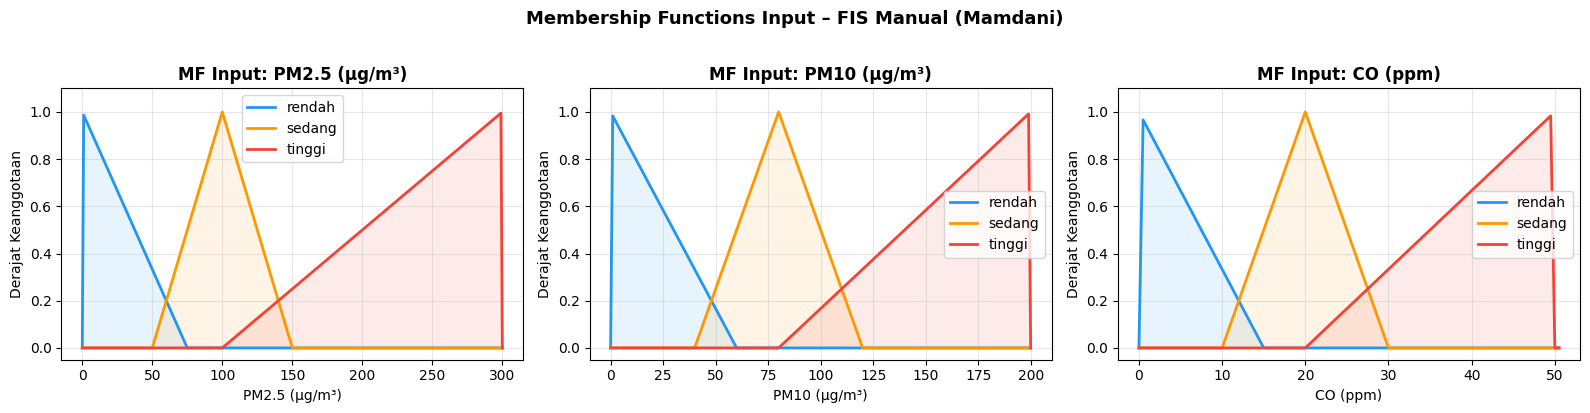

In [ ]:
# Plot MF Input: PM2.5, PM10, CO
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
colors = ['#2196F3', '#FF9800', '#F44336']
labels_mf = ['rendah', 'sedang', 'tinggi']

universes = [U_PM25, U_PM10, U_CO]
mf_sets   = [MF_PM25_MANUAL, MF_PM10_MANUAL, MF_CO_MANUAL]
titles    = ['PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'CO (ppm)']

for ax, universe, mf_set, title in zip(axes, universes, mf_sets, titles):
    for (name, params), color in zip(mf_set.items(), colors):
        y = trimf(universe, params)
        ax.plot(universe, y, label=name, color=color, linewidth=2)
        ax.fill_between(universe, y, alpha=0.1, color=color)
    ax.set_title(f'MF Input: {title}', fontweight='bold')
    ax.set_xlabel(title)
    ax.set_ylabel('Derajat Keanggotaan')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.05, 1.1)

plt.suptitle('Membership Functions Input – FIS Manual (Mamdani)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('mf_input_manual.png', dpi=150, bbox_inches='tight')
plt.show()


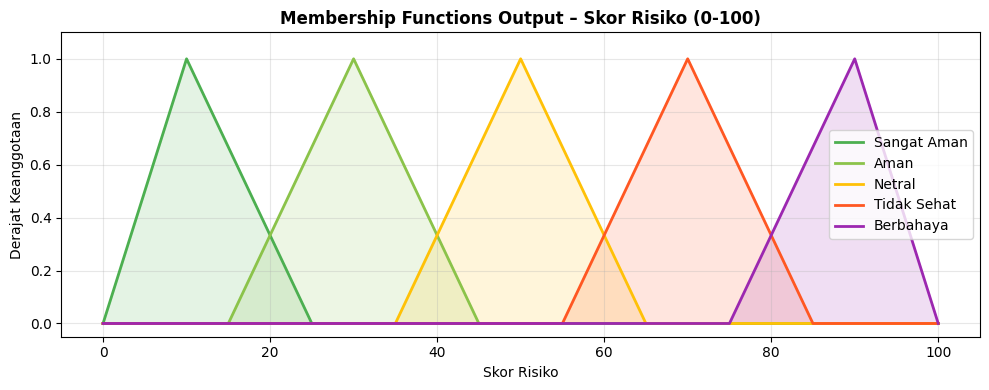

In [ ]:
# Plot MF Output
fig, ax = plt.subplots(figsize=(10, 4))
colors_out = ['#4CAF50', '#8BC34A', '#FFC107', '#FF5722', '#9C27B0']
for (name, params), color in zip(MF_OUT_MANUAL.items(), colors_out):
    y = trimf(U_OUT, params)
    ax.plot(U_OUT, y, label=name, color=color, linewidth=2)
    ax.fill_between(U_OUT, y, alpha=0.15, color=color)

ax.set_title('Membership Functions Output – Skor Risiko (0-100)', fontweight='bold')
ax.set_xlabel('Skor Risiko')
ax.set_ylabel('Derajat Keanggotaan')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.1)
plt.tight_layout()
plt.savefig('mf_output_manual.png', dpi=150, bbox_inches='tight')
plt.show()


#FIS + GA

In [ ]:
# Encode parameter MF ke chromosome
# Chromosome: [pm25_r_a, pm25_r_b, pm25_r_c, pm25_s_a, ..., co_t_c] = 27 gen
def params_to_chromosome(mf_pm25, mf_pm10, mf_co):
    chrom = []
    for mf in [mf_pm25, mf_pm10, mf_co]:
        for params in mf.values():
            chrom.extend(list(params))
    return np.array(chrom, dtype=float)

def chromosome_to_params(chrom):
    """Rekonstruksi MF dari chromosome."""
    keys = ['rendah', 'sedang', 'tinggi']
    idx = 0
    mfs = []
    for _ in range(3):  # 3 variabel input
        mf = {}
        for k in keys:
            a, b, c = chrom[idx], chrom[idx+1], chrom[idx+2]
            # Pastikan a <= b <= c (constraint)
            a, b, c = sorted([a, b, c])
            mf[k] = (a, b, c)
            idx += 3
        mfs.append(mf)
    return mfs[0], mfs[1], mfs[2]

# Chromosome awal dari MF manual
init_chrom = params_to_chromosome(MF_PM25_MANUAL, MF_PM10_MANUAL, MF_CO_MANUAL)
print(f"Panjang chromosome: {len(init_chrom)} gen")
print(f"Chromosome awal (5 nilai pertama): {init_chrom[:5]}")


Panjang chromosome: 27 gen
Chromosome awal (5 nilai pertama): [  0.   0.  75.  50. 100.]


In [ ]:
# Sample data training untuk GA (subset)
N_SAMPLE = 300  # sample untuk mempercepat GA
idx_sample = np.random.choice(len(X_train), N_SAMPLE, replace=False)
X_ga_sample = X_train[idx_sample]
y_ga_sample = y_train[idx_sample]

def evaluate_fis_params(mf25, mf10, mfco):
    """Hitung accuracy FIS dengan parameter MF tertentu."""
    preds = []
    for row in X_ga_sample:
        score = _run_fis(row[0], row[1], row[2],
                         mf25, mf10, mfco,
                         MF_OUT_MANUAL, RULES_MANUAL)
        preds.append(score_label_to_class(score_to_label(score)))
    return accuracy_score(y_ga_sample, preds)

# Fitness function untuk PyGAD
def fitness_func(ga_instance, solution, solution_idx):
    mf25, mf10, mfco = chromosome_to_params(solution)
    acc = evaluate_fis_params(mf25, mf10, mfco)
    return acc  # maksimasi accuracy

print("Fitness function siap.")


Fitness function siap.


In [ ]:
# Konfigurasi dan Jalankan GA (konfigurasi terbaik)
print("Menjalankan Genetic Algorithm... (harap tunggu)")

# Batas nilai gen: sesuai range masing-masing variabel
gene_space_pm25 = [{'low': 0,  'high': 300}] * 9
gene_space_pm10 = [{'low': 0,  'high': 200}] * 9
gene_space_co   = [{'low': 0,  'high': 50}]  * 9
gene_space = gene_space_pm25 + gene_space_pm10 + gene_space_co

ga_instance = pygad.GA(
    num_generations     = 30,          # jumlah generasi
    num_parents_mating  = 5,
    fitness_func        = fitness_func,
    sol_per_pop         = 20,          # ukuran populasi
    num_genes           = 27,
    gene_space          = gene_space,
    parent_selection_type = "tournament",
    crossover_type      = "single_point",
    mutation_type       = "random",
    mutation_percent_genes = 15,
    keep_elitism        = 2,
    initial_population  = None,
    suppress_warnings   = True
)

ga_instance.run()

# Ambil solusi terbaik
solution, solution_fitness, _ = ga_instance.best_solution()
print(f"\nGA selesai!")
print(f"   Best fitness (accuracy): {solution_fitness:.4f} ({solution_fitness*100:.2f}%)")

# Update MF dengan hasil GA
MF_PM25_GA, MF_PM10_GA, MF_CO_GA = chromosome_to_params(solution)
print("\nMF PM2.5 hasil GA:")
for k, v in MF_PM25_GA.items():
    print(f"   {k}: {tuple(round(x,2) for x in v)}")


Menjalankan Genetic Algorithm... (harap tunggu)

GA selesai!
   Best fitness (accuracy): 0.9267 (92.67%)

MF PM2.5 hasil GA:
   rendah: (np.float64(92.39), np.float64(216.79), np.float64(296.17))
   sedang: (np.float64(101.07), np.float64(109.01), np.float64(212.35))
   tinggi: (np.float64(170.75), np.float64(227.48), np.float64(285.58))


In [ ]:
# Fungsi prediksi FIS + GA
def predict_fis_ga_raw(pm25, pm10, co):
    """Prediksi dengan FIS teroptimasi GA, return label string."""
    score = _run_fis(pm25, pm10, co,
                     MF_PM25_GA, MF_PM10_GA, MF_CO_GA,
                     MF_OUT_MANUAL, RULES_MANUAL)
    return score_to_label(score)

# Evaluasi FIS + GA
y_fis_pred_ga = []
for i in range(len(X_test)):
    pm25, pm10, co = X_test[i]
    label = predict_fis_ga_raw(pm25, pm10, co)
    y_fis_pred_ga.append(score_label_to_class(label))

y_fis_pred_ga = np.array(y_fis_pred_ga)
acc_fis_ga = accuracy_score(y_test, y_fis_pred_ga)
print(f"Accuracy FIS + GA: {acc_fis_ga:.4f} ({acc_fis_ga*100:.2f}%)")


Accuracy FIS + GA: 0.9115 (91.15%)


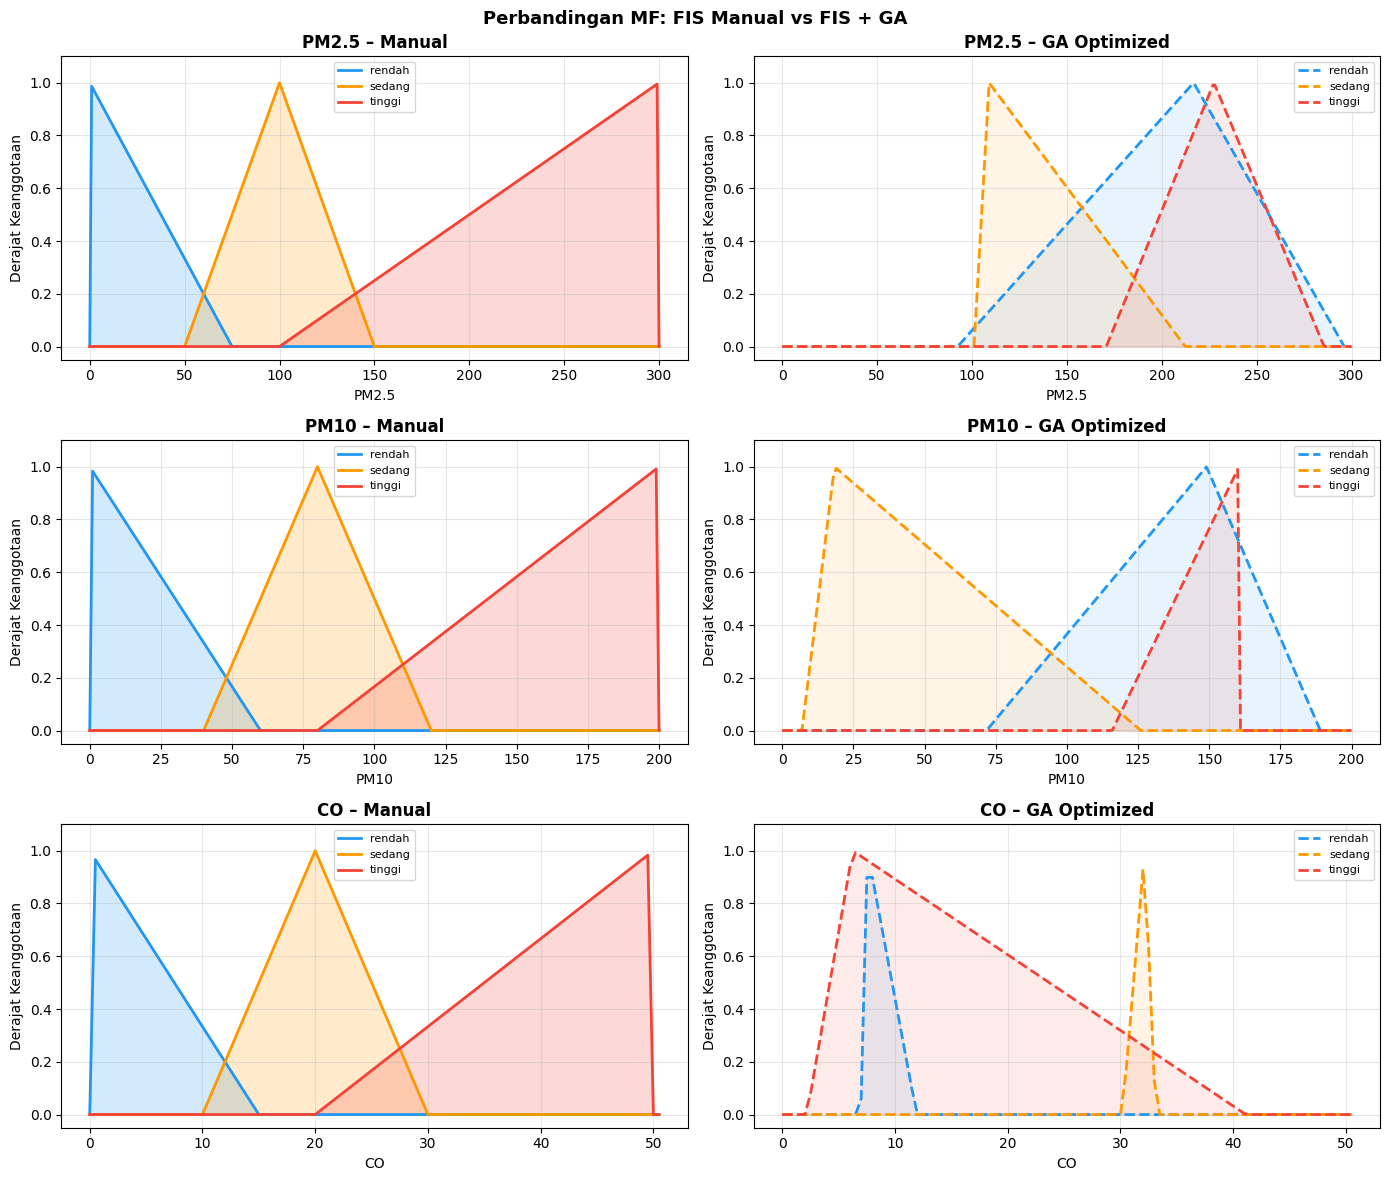


Analisis Pergeseran Kurva MF:

  [PM2.5]
    rendah: puncak 0.0 → 216.79  (Δ=216.79 ↑ naik)
    sedang: puncak 100.0 → 109.01  (Δ=9.01 ↑ naik)
    tinggi: puncak 300.0 → 227.48  (Δ=-72.52 ↓ turun)

  [PM10]
    rendah: puncak 0.0 → 149.06  (Δ=149.06 ↑ naik)
    sedang: puncak 80.0 → 18.35  (Δ=-61.65 ↓ turun)
    tinggi: puncak 200.0 → 160.46  (Δ=-39.54 ↓ turun)

  [CO]
    rendah: puncak 0.0 → 7.56  (Δ=7.56 ↑ naik)
    sedang: puncak 20.0 → 32.14  (Δ=12.14 ↑ naik)
    tinggi: puncak 50.0 → 6.25  (Δ=-43.75 ↓ turun)


In [ ]:
# Plot perbandingan MF Manual vs GA untuk 3 variabel input
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
variables   = ['PM2.5', 'PM10', 'CO']
universes_v = [U_PM25, U_PM10, U_CO]
mf_manuals  = [MF_PM25_MANUAL, MF_PM10_MANUAL, MF_CO_MANUAL]
mf_gas      = [MF_PM25_GA,     MF_PM10_GA,     MF_CO_GA]
mf_keys     = ['rendah', 'sedang', 'tinggi']
colors_mf   = ['#2196F3', '#FF9800', '#F44336']

for row, (var, univ, mf_man, mf_ga) in enumerate(
        zip(variables, universes_v, mf_manuals, mf_gas)):
    for col, (title, mf_set, ls, alpha) in enumerate([
            ('Manual', mf_man, '-', 0.2),
            ('GA Optimized', mf_ga, '--', 0.1)]):
        ax = axes[row][col]
        for key, color in zip(mf_keys, colors_mf):
            y = trimf(univ, mf_set[key])
            ax.plot(univ, y, label=key, color=color, linewidth=2, linestyle=ls)
            ax.fill_between(univ, y, alpha=alpha, color=color)
        ax.set_title(f'{var} – {title}', fontweight='bold')
        ax.set_xlabel(var)
        ax.set_ylabel('Derajat Keanggotaan')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.set_ylim(-0.05, 1.1)

plt.suptitle('Perbandingan MF: FIS Manual vs FIS + GA',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('mf_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Analisis pergeseran kurva
print("\nAnalisis Pergeseran Kurva MF:")
for var, mf_man, mf_ga in zip(variables, mf_manuals, mf_gas):
    print(f"\n  [{var}]")
    for key in mf_keys:
        a_man, b_man, c_man = mf_man[key]
        a_ga,  b_ga,  c_ga  = mf_ga[key]
        shift = round(b_ga - b_man, 2)
        direction = "↑ naik" if shift > 0 else "↓ turun"
        print(f"    {key}: puncak {b_man:.1f} → {b_ga:.2f}  (Δ={shift} {direction})")


In [ ]:
# Definisi skenario eksperimen
scenarios = [
    {'label': 'Pop=10, Gen=15 (kecil-sedikit)', 'sol_per_pop': 10, 'num_gen': 15},
    {'label': 'Pop=10, Gen=40 (kecil-banyak)',  'sol_per_pop': 10, 'num_gen': 40},
    {'label': 'Pop=20, Gen=15 (besar-sedikit)', 'sol_per_pop': 20, 'num_gen': 15},
    {'label': 'Pop=20, Gen=40 (besar-banyak)',  'sol_per_pop': 20, 'num_gen': 40},
]

ablation_results = {}

for sc in scenarios:
    print(f"\nSkenario: {sc['label']}")
    fitness_history = []

    def fitness_func_ablation(ga_inst, sol, sol_idx):
        mf25, mf10, mfco = chromosome_to_params(sol)
        return evaluate_fis_params(mf25, mf10, mfco)

    ga_sc = pygad.GA(
        num_generations       = sc['num_gen'],
        num_parents_mating    = max(2, sc['sol_per_pop'] // 4),
        fitness_func          = fitness_func_ablation,
        sol_per_pop           = sc['sol_per_pop'],
        num_genes             = 27,
        gene_space            = gene_space,
        parent_selection_type = "tournament",
        crossover_type        = "single_point",
        mutation_type         = "random",
        mutation_percent_genes = 15,
        keep_elitism          = 1,
        suppress_warnings     = True,
        on_generation         = lambda ga: fitness_history.append(
            ga.best_solutions_fitness[-1])
    )
    ga_sc.run()

    sol_sc, fit_sc, _ = ga_sc.best_solution()
    mf25_sc, mf10_sc, mfco_sc = chromosome_to_params(sol_sc)

    # Evaluasi pada data test
    preds_sc = []
    for row in X_test:
        sc_score = _run_fis(row[0], row[1], row[2],
                            mf25_sc, mf10_sc, mfco_sc,
                            MF_OUT_MANUAL, RULES_MANUAL)
        preds_sc.append(score_label_to_class(score_to_label(sc_score)))
    acc_sc = accuracy_score(y_test, preds_sc)

    ablation_results[sc['label']] = {
        'fitness_history': fitness_history,
        'best_fitness'   : fit_sc,
        'test_accuracy'  : acc_sc
    }
    print(f"   Best fitness: {fit_sc:.4f} | Test accuracy: {acc_sc:.4f}")

print("\nSemua skenario selesai!")



Skenario: Pop=10, Gen=15 (kecil-sedikit)
   Best fitness: 0.9033 | Test accuracy: 0.9038

Skenario: Pop=10, Gen=40 (kecil-banyak)
   Best fitness: 0.9600 | Test accuracy: 0.9538

Skenario: Pop=20, Gen=15 (besar-sedikit)
   Best fitness: 0.9567 | Test accuracy: 0.9577

Skenario: Pop=20, Gen=40 (besar-banyak)
   Best fitness: 0.9267 | Test accuracy: 0.9423

Semua skenario selesai!


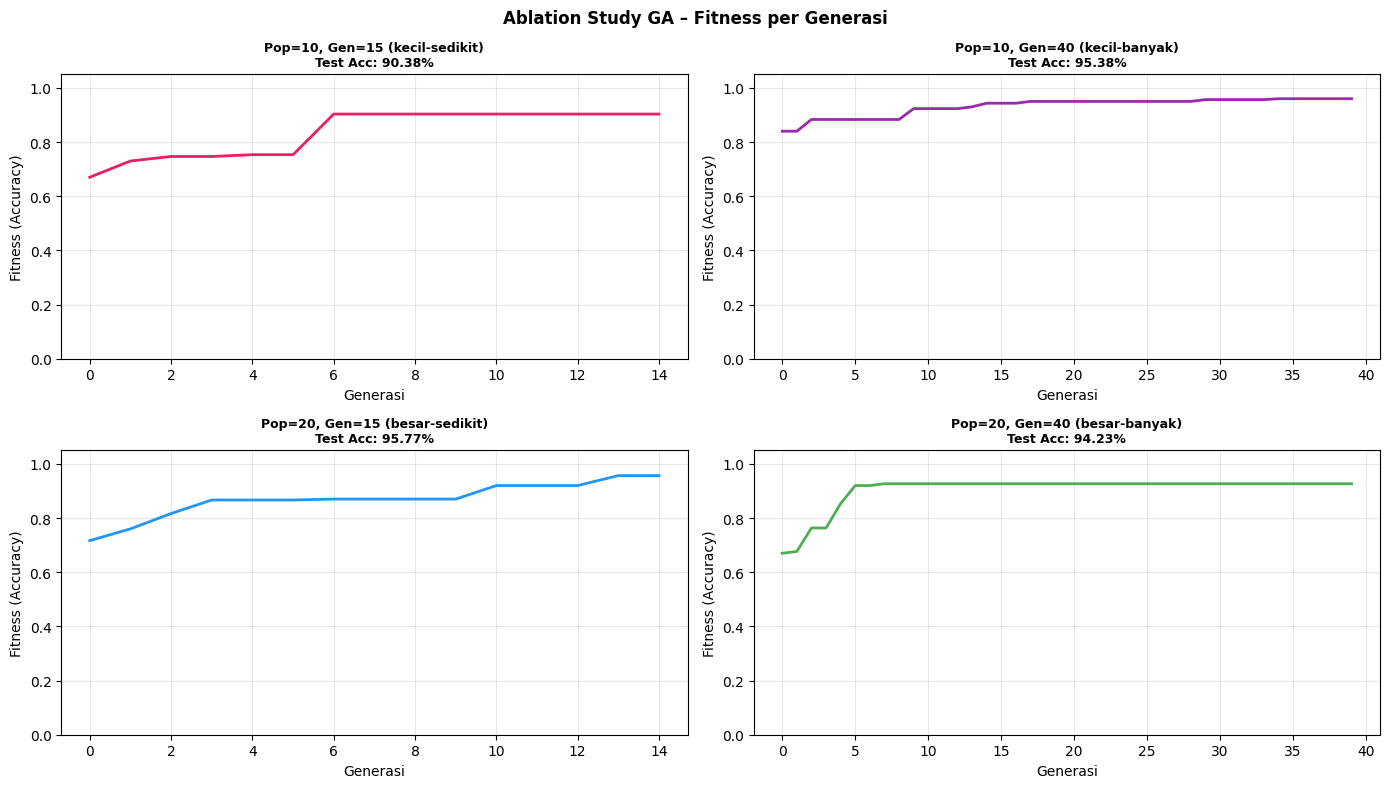


Ringkasan Ablation Study:
Skenario                                    Best Fitness   Test Accuracy
------------------------------------------------------------------------
Pop=10, Gen=15 (kecil-sedikit)                    0.9033          0.9038
Pop=10, Gen=40 (kecil-banyak)                     0.9600          0.9538
Pop=20, Gen=15 (besar-sedikit)                    0.9567          0.9577
Pop=20, Gen=40 (besar-banyak)                     0.9267          0.9423

Parameter terbaik: Pop=20, Gen=15 (besar-sedikit)
   Alasan: konvergensi stabil dengan akurasi test tertinggi.


In [ ]:
# ── Visualisasi: Fitness vs Generasi untuk setiap skenario ──
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
colors_sc = ['#E91E63', '#9C27B0', '#2196F3', '#4CAF50']

for ax, (label, res), color in zip(axes.flat, ablation_results.items(), colors_sc):
    ax.plot(res['fitness_history'], color=color, linewidth=2)
    ax.set_title(f"{label}\nTest Acc: {res['test_accuracy']*100:.2f}%",
                 fontsize=9, fontweight='bold')
    ax.set_xlabel('Generasi')
    ax.set_ylabel('Fitness (Accuracy)')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1.05)

plt.suptitle('Ablation Study GA – Fitness per Generasi', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('ga_ablation.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Ringkasan tabel ablation ──
print("\nRingkasan Ablation Study:")
print(f"{'Skenario':<40} {'Best Fitness':>15} {'Test Accuracy':>15}")
print("-" * 72)
for label, res in ablation_results.items():
    print(f"{label:<40} {res['best_fitness']:>15.4f} {res['test_accuracy']:>15.4f}")

# Pilih skenario terbaik
best_sc = max(ablation_results, key=lambda k: ablation_results[k]['test_accuracy'])
print(f"\nParameter terbaik: {best_sc}")
print("   Alasan: konvergensi stabil dengan akurasi test tertinggi.")


#FIS + ANN

In [ ]:
# --- Penyesuaian Preprocessing untuk ANN ---
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.utils import to_categorical

# 1. Gunakan MinMaxScaler agar range data masuk ke 0-1
# Ini sangat krusial agar nilai input sinkron dengan logika MF (0-1)
# dan mempermudah tuning bias yang sudah disuntikkan (-0.2, 0.5, 0.9)
scaler = MinMaxScaler()

# SESUAIKAN: Ambil dari X_train dan X_test hasil split Langkah 6
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# 2. One-hot encoding label untuk Output Layer ANN
N_CLASSES = len(CLASS_ORDER)

# SESUAIKAN: Ambil dari y_train dan y_test hasil split Langkah 6
y_train_oh = to_categorical(y_train, num_classes=N_CLASSES)
y_test_oh  = to_categorical(y_test,  num_classes=N_CLASSES)

# 3. Verifikasi Data
print(f"Fitur yang digunakan : {FITUR_SAMA}")
print(f"Input shape (Train)  : {X_train_sc.shape}") # Harus (N, 3)
print(f"Output shape (Train) : {y_train_oh.shape}") # Harus (N, 4)
print(f"Jumlah kelas         : {N_CLASSES} → {CLASS_ORDER}")

Fitur yang digunakan : ['pm25', 'pm10', 'co']
Input shape (Train)  : (1040, 3)
Output shape (Train) : (1040, 4)
Jumlah kelas         : 4 → ['Sangat Aman', 'Aman', 'Tidak Sehat', 'Berbahaya']


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

tf.random.set_seed(42)

# Membangun model yang strukturnya mengikuti logika FIS
model_ann = Sequential([
    # Layer 1: Fuzzification Layer
    # 9 neuron = (PM25: R,S,T) + (PM10: R,S,T) + (CO: R,S,T)
    Dense(9, activation='sigmoid', input_shape=(3,), name='fuzzification_layer'),

    # Layer 2: Rule Inference Layer
    # Layer ini merepresentasikan kombinasi Rules (Knowledge Base)
    Dense(16, activation='relu', name='rule_base'),

    # Layer 3: Defuzzification (Output)
    BatchNormalization(),
    Dropout(0.2),
    Dense(N_CLASSES, activation='softmax', name='output_class')
])

# Fungsi untuk menyuntikkan "Logika FIS" ke dalam bobot ANN
def inject_fis_parameters(model):
    # Ambil bobot layer fuzzifikasi
    weights, biases = model.get_weights()[0], model.get_weights()[1]

    # Contoh: Kita set bias agar neuron aktif pada area MF Sedang/Tinggi
    # Dalam Neuro-Fuzzy, bias seringkali mewakili 'center' dari MF
    new_biases = np.array([
        -0.2, 0.5, 0.9,  # Bias untuk PM2.5 (Rendah, Sedang, Tinggi)
        -0.2, 0.5, 0.9,  # Bias untuk PM10  (Rendah, Sedang, Tinggi)
        -0.2, 0.5, 0.9   # Bias untuk CO    (Rendah, Sedang, Tinggi)
    ])

    # Set kembali bobot yang sudah terinspirasi dari FIS
    model.layers[0].set_weights([weights, new_biases])
    print("Logika FIS berhasil disuntikkan ke bobot awal ANN.")

inject_fis_parameters(model_ann)

model_ann.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_ann.summary()

Logika FIS berhasil disuntikkan ke bobot awal ANN.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ fuzzification_layer (Dense)     │ (None, 9)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rule_base (Dense)               │ (None, 16)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_class (Dense)            │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 328 (1.28 KB)

 Trainable params: 296 (1.16 KB)

 Non-trainable params: 32 (128.00 B)

In [ ]:
# Training ANN
from tensorflow.keras.callbacks import EarlyStopping

# Training dengan Early Stopping untuk mencegah overfitting hasil tuning
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history = model_ann.fit(
    X_train_sc, y_train_oh,
    epochs=150, # Beri epoch lebih banyak karena learning rate bisa kita kecilkan
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

print(f"\nTraining selesai di epoch {len(history.history['loss'])}")


Epoch 1/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7404 - loss: 0.8357 - val_accuracy: 0.6779 - val_loss: 0.7512
Epoch 2/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8918 - loss: 0.3894 - val_accuracy: 0.6779 - val_loss: 0.7246
Epoch 3/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8930 - loss: 0.3588 - val_accuracy: 0.6779 - val_loss: 0.7837
Epoch 4/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9026 - loss: 0.3280 - val_accuracy: 0.6779 - val_loss: 0.8299
Epoch 5/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8990 - loss: 0.3291 - val_accuracy: 0.6779 - val_loss: 0.8365
Epoch 6/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8990 - loss: 0.3213 - val_accuracy: 0.6779 - val_loss: 0.8294
Epoch 7/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8906 - loss: 0.2988 - val_accuracy: 0.6779 - val_loss: 0.7830
Epoch 8/150
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9075 - loss: 0.2902 - val_accuracy: 0.6779 - 

In [ ]:
# Evaluasi ANN
y_ann_pred_prob = model_ann.predict(X_test_sc)
y_ann_pred      = np.argmax(y_ann_pred_prob, axis=1)

acc_ann = accuracy_score(y_test, y_ann_pred)
print(f"Accuracy FIS + ANN: {acc_ann:.4f} ({acc_ann*100:.2f}%)")
print()
print("Classification Report:")
print(classification_report(y_test, y_ann_pred, target_names=CLASS_ORDER))


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Accuracy FIS + ANN: 0.9346 (93.46%)

Classification Report:
              precision    recall  f1-score   support

 Sangat Aman       0.00      0.00      0.00         7
        Aman       0.91      0.99      0.95       172
 Tidak Sehat       0.99      0.90      0.94        80
   Berbahaya       0.00      0.00      0.00         1

    accuracy                           0.93       260
   macro avg       0.48      0.47      0.47       260
weighted avg       0.91      0.93      0.92       260



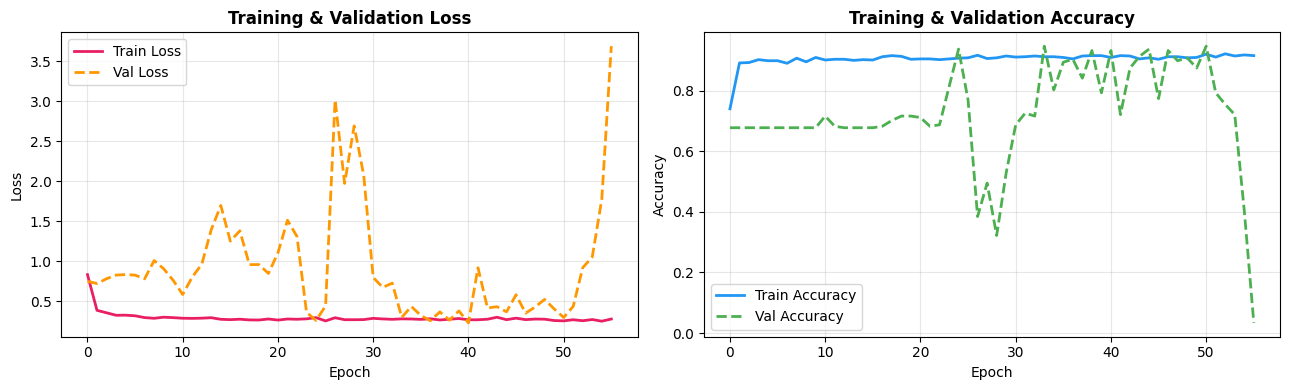

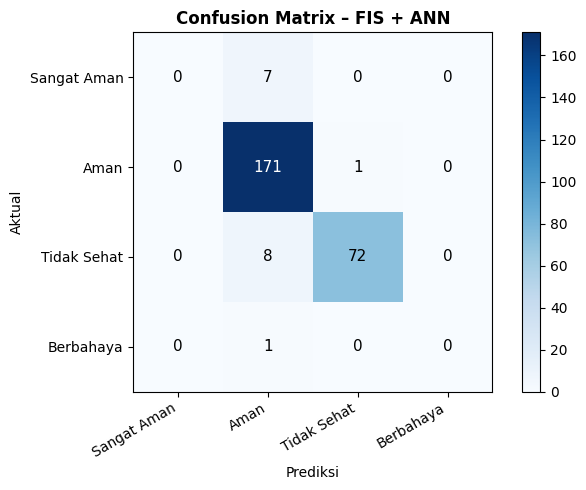

In [ ]:
# Visualisasi Loss & Accuracy ANN
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(history.history['loss'],     label='Train Loss',     color='#E91E63', lw=2)
ax1.plot(history.history['val_loss'], label='Val Loss',       color='#FF9800', lw=2, ls='--')
ax1.set_title('Training & Validation Loss', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(history.history['accuracy'],     label='Train Accuracy', color='#2196F3', lw=2)
ax2.plot(history.history['val_accuracy'], label='Val Accuracy',   color='#4CAF50', lw=2, ls='--')
ax2.set_title('Training & Validation Accuracy', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ann_training.png', dpi=150, bbox_inches='tight')
plt.show()

# Confusion Matrix
cm = confusion_matrix(y_test, y_ann_pred)
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im)
ax.set_xticks(range(N_CLASSES)); ax.set_yticks(range(N_CLASSES))
ax.set_xticklabels(CLASS_ORDER, rotation=30, ha='right')
ax.set_yticklabels(CLASS_ORDER)
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=11)
ax.set_xlabel('Prediksi'); ax.set_ylabel('Aktual')
ax.set_title('Confusion Matrix – FIS + ANN', fontweight='bold')
plt.tight_layout()
plt.savefig('ann_confusion.png', dpi=150, bbox_inches='tight')
plt.show()


Perbandingan Model

     Model  Accuracy Accuracy (%)
FIS Manual  0.665385       66.54%
  FIS + GA  0.911538       91.15%
 FIS + ANN  0.934615       93.46%

Model Terbaik: FIS + ANN


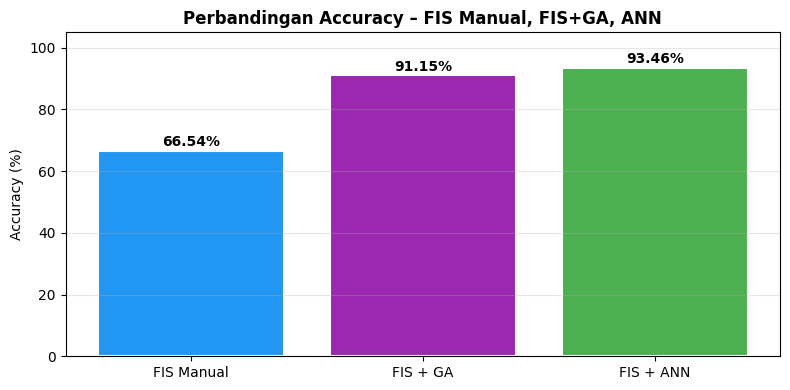

In [ ]:
# Tabel perbandingan accuracy
comparison = {
    'Model'   : ['FIS Manual', 'FIS + GA', 'FIS + ANN'],
    'Accuracy': [acc_fis_manual, acc_fis_ga, acc_ann],
    'Accuracy (%)': [f"{acc_fis_manual*100:.2f}%", f"{acc_fis_ga*100:.2f}%", f"{acc_ann*100:.2f}%"]
}
df_compare = pd.DataFrame(comparison)
print(df_compare.to_string(index=False))

best_model = df_compare.loc[df_compare['Accuracy'].idxmax(), 'Model']
print(f"\nModel Terbaik: {best_model}")

# Bar chart perbandingan
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(comparison['Model'], [a*100 for a in comparison['Accuracy']],
              color=['#2196F3', '#9C27B0', '#4CAF50'], edgecolor='white', linewidth=1.5)
for bar, acc in zip(bars, comparison['Accuracy']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{acc*100:.2f}%", ha='center', va='bottom', fontweight='bold')
ax.set_ylabel('Accuracy (%)'); ax.set_ylim(0, 105)
ax.set_title('Perbandingan Accuracy – FIS Manual, FIS+GA, ANN', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

#Export Model

In [ ]:
# Simpan FIS Manual → JSON
fis_manual_config = {
    'mf_pm25' : {k: list(v) for k, v in MF_PM25_MANUAL.items()},
    'mf_pm10' : {k: list(v) for k, v in MF_PM10_MANUAL.items()},
    'mf_co'   : {k: list(v) for k, v in MF_CO_MANUAL.items()},
    'mf_out'  : {k: list(v) for k, v in MF_OUT_MANUAL.items()},
    'rules'   : [list(r) for r in RULES_MANUAL],
    'classes' : CLASS_ORDER
}
with open('fis_manual_config.json', 'w') as f:
    json.dump(fis_manual_config, f, indent=2)
print("Simpan: fis_manual_config.json  – parameter MF & rules FIS manual")

# Simpan FIS + GA → JSON
fis_ga_config = {
    'mf_pm25' : {k: list(v) for k, v in MF_PM25_GA.items()},
    'mf_pm10' : {k: list(v) for k, v in MF_PM10_GA.items()},
    'mf_co'   : {k: list(v) for k, v in MF_CO_GA.items()},
    'mf_out'  : {k: list(v) for k, v in MF_OUT_MANUAL.items()},
    'rules'   : [list(r) for r in RULES_MANUAL],
    'classes' : CLASS_ORDER
}
with open('fis_ga_config.json', 'w') as f:
    json.dump(fis_ga_config, f, indent=2)
print("Simpan: fis_ga_config.json      – parameter MF hasil optimasi GA")

# Simpan ANN → .h5
model_ann.save('ann_model.h5')
print("Simpan: ann_model.h5            – model ANN terlatih")

# Simpan hanya bobot (lebih aman dari error versi)
model_ann.save_weights('model_weights.weights.h5')

# Simpan scaler & label encoder → pickle
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("Simpan: scaler.pkl              – StandardScaler untuk normalisasi ANN")

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump({'classes': CLASS_ORDER}, f)
print("Simpan: label_encoder.pkl       – mapping label kelas")


Simpan: fis_manual_config.json  – parameter MF & rules FIS manual
Simpan: fis_ga_config.json      – parameter MF hasil optimasi GA
Simpan: ann_model.h5            – model ANN terlatih
Simpan: scaler.pkl              – StandardScaler untuk normalisasi ANN
Simpan: label_encoder.pkl       – mapping label kelas


In [ ]:
# 1. Tentukan Input Manual (Silakan ganti angka-angkanya di sini)
test_pm25 = 74.20
test_pm10 = 58.00
test_co   = 12.80

# Persiapkan data untuk ANN (harus di-scale menggunakan scaler yang sudah di-fit)
input_data = np.array([[test_pm25, test_pm10, test_co]])
input_data_sc = scaler.transform(input_data) # Pakai MinMaxScaler kamu

# 2. Ambil Hasil dari Ketiga Model
# --- Jalur A: FIS Manual ---
res_manual_label = predict_fis_raw(test_pm25, test_pm10, test_co)

# --- Jalur B: FIS + GA ---
res_ga_label = predict_fis_ga_raw(test_pm25, test_pm10, test_co)

# --- Jalur C: FIS + ANN ---
res_ann_prob = model_ann.predict(input_data_sc, verbose=0)
res_ann_idx = np.argmax(res_ann_prob)
res_ann_label = CLASS_ORDER[res_ann_idx]

# 3. Tampilkan Hasil
print(f"=== TESTING INPUT MANUAL ===")
print(f"Input: PM2.5={test_pm25}, PM10={test_pm10}, CO={test_co}")
print("-" * 30)
print(f"Hasil FIS Manual : {res_manual_label}")
print(f"Hasil FIS + GA   : {res_ga_label}")
print(f"Hasil FIS + ANN  : {res_ann_label}")

# Opsional: Liat keyakinan ANN
print(f"Confidence ANN   : {np.max(res_ann_prob)*100:.2f}%")

=== TESTING INPUT MANUAL ===
Input: PM2.5=74.2, PM10=58.0, CO=12.8
------------------------------
Hasil FIS Manual : Netral
Hasil FIS + GA   : Netral
Hasil FIS + ANN  : Aman
Confidence ANN   : 98.84%
